In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sc
from scipy import stats
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

In [52]:
ROOT = '../data/processed/'
DATASET = ROOT+'2024_saliva_experiment/df_ph_pilot_saliva_sweat_2025.csv'

df_experiment= pd.read_csv(DATASET)

In [53]:
df_experiment

,condition,measurement,pH
0,Saliva_Control,pH Meter,7.400000
1,Saliva_After_Exercise,pH Meter,7.200000
2,Saliva_After_Eating_10,pH Meter,7.600000
3,Sweat_After_Exercise,pH Meter,7.200000
4,Saliva_Control,Colorimetric Sensors,7.234826
...,...,...,...
5300,Saliva_After_Eating_25,Colorimetric Sensors,6.833331
5301,Saliva_After_Eating_25,Colorimetric Sensors,7.103402
5302,Saliva_After_Eating_25,Colorimetric Sensors,7.174109
5303,Saliva_After_Eating_25,Colorimetric Sensors,7.367917


In [54]:
# Separate df per sensor type

df_ph = df_experiment[df_experiment['measurement'] == 'pH Meter'].reset_index()

df_color_sensors = df_experiment[df_experiment['measurement'] == 'Colorimetric Sensors'].reset_index()


In [55]:
df_color_sensors['condition'].unique()

array(['Saliva_Control', 'Saliva_After_Exercise', 'Sweat_After_Exercise',
       'Saliva_After_Eating_10', 'Saliva_After_Eating_25'], dtype=object)

In [56]:
# Sample data for three groups
conditions = df_color_sensors['condition'].unique()

dict_conditions = {}
for c in conditions:
    dict_conditions[c] = df_color_sensors[df_color_sensors['condition']==c]['pH'].to_numpy()

# Perform the Kruskal-Wallis H-test
statistic, p_value = stats.kruskal(
    dict_conditions['Saliva_Control'],
    dict_conditions['Saliva_After_Exercise'],
    # dict_conditions['Sweat_After_Exercise'],
    dict_conditions['Saliva_After_Eating_10'],
    dict_conditions['Saliva_After_Eating_25'],
)

print(f"H-statistic: {statistic:.3f}")
print(f"P-value: {p_value:.8e}")


# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: significant differences exist between groups.")
else:
    print("Fail to reject the null hypothesis: no significant differences.")

H-statistic: 3902.369
P-value: 0.00000000e+00
Reject the null hypothesis: significant differences exist between groups.


COMPARISON
Saliva_Control  vs.  Saliva_After_Exercise
U statistic: 2581322.0
P-value: 0.000e+00
Reject null hypothesis: Significant difference between groups.


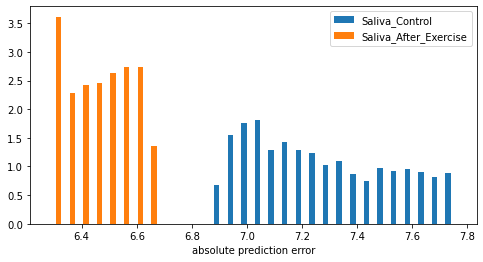

COMPARISON
Saliva_Control  vs.  Saliva_After_Eating_10
U statistic: 65835.0
P-value: 2.562e-310
Reject null hypothesis: Significant difference between groups.


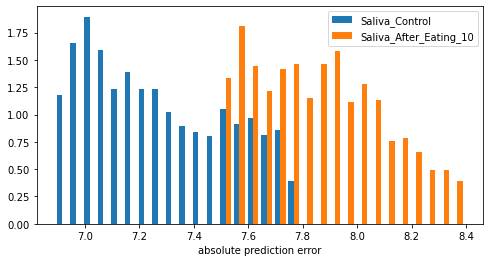

In [57]:
# Statistical Test

CONDITION_A = 'Saliva_Control'

CONDITIONS_B = ['Saliva_After_Exercise', 'Saliva_After_Eating_10']

alternative_array = ['greater', 'less']

p_vals_all = []

for i, temp_condition in enumerate(CONDITIONS_B):
    statistic, p_value = mannwhitneyu(
        dict_conditions[CONDITION_A], 
        dict_conditions[temp_condition], 
        alternative=alternative_array[i]
    )

    print('COMPARISON')
    print(CONDITION_A, ' vs. ',temp_condition)
    print("U statistic:", statistic)
    print(f"P-value: {p_value:.3e}")
    if p_value < 0.05:
        print("Reject null hypothesis: Significant difference between groups.")
    else:
        print("Fail to reject null hypothesis: No significant difference.")

    # Plot comparison
    plt.figure(figsize=(8, 4))
    plt.xlabel('absolute prediction error')
    plt.hist([dict_conditions[CONDITION_A], dict_conditions[temp_condition]], bins=30, label=[CONDITION_A,temp_condition], density=True)
    plt.legend(loc="upper right")
    plt.show()
    
    # Save p-values for correction
    p_vals_all.append(p_value)


COMPARISON
Saliva_After_Exercise  vs.  Saliva_After_Eating_10
U statistic: 0.0
P-value: 0.000000000000000e+00
Reject null hypothesis: Significant difference between groups.


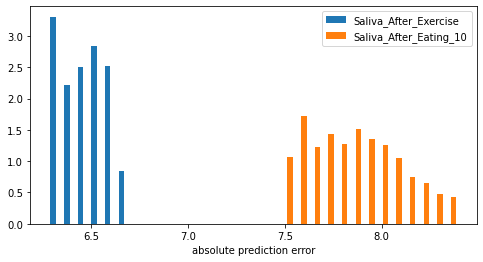

In [58]:
# Statistical Test

CONDITION_A = 'Saliva_After_Exercise'

CONDITION_B = 'Saliva_After_Eating_10'


statistic, p_value = mannwhitneyu(
    dict_conditions[CONDITION_A], 
    dict_conditions[CONDITION_B], 
    alternative='less'
)

print('COMPARISON')
print(CONDITION_A, ' vs. ',CONDITION_B)
print("U statistic:", statistic)
print(f"P-value: {p_value:.15e}")
if p_value < 0.05:
    print("Reject null hypothesis: Significant difference between groups.")
else:
    print("Fail to reject null hypothesis: No significant difference.")

# Plot comparison
plt.figure(figsize=(8, 4))
plt.xlabel('absolute prediction error')
plt.hist([dict_conditions[CONDITION_A], dict_conditions[CONDITION_B]], bins=30, 
         label=[CONDITION_A,CONDITION_B], density=True)
plt.legend(loc="upper right")
plt.show()

# Save p-values for correction
p_vals_all.append(p_value)

In [59]:
from statsmodels.stats.multitest import multipletests
print('original p-vals:',p_vals_all)
rejected, p_adjusted, _, _ = multipletests(p_vals_all, alpha=0.05, method='fdr_bh')
print('adjusted p-vals:',p_adjusted)

original p-vals: [0.0, 2.56225653641914e-310, 0.0]
adjusted p-vals: [0.00000000e+000 2.56225654e-310 0.00000000e+000]


## Differential Changes

In [28]:
# Min Max Range
global_Deviation_ph = (df_color_sensors['pH'].max()-df_color_sensors['pH'].min())
print(global_Deviation_ph)

2.111319659887335


In [39]:
# Percentile Change
median_Baseline = df_color_sensors[df_color_sensors['condition']=='Saliva_Control']['pH'].median()
median_exercise = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Exercise']['pH'].median()
median_post_10 = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Eating_10']['pH'].median()
median_post_25 = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Eating_25']['pH'].median()

print('Medians', median_Baseline, median_exercise, median_post_10)

# Baseline vs Exercise
change_in_iqr_exe = (median_exercise - median_Baseline)/global_Deviation_ph
print('change_in_exe', change_in_iqr_exe*100)

# Baseline vs PostPrandial 10
change_in_iqr_10 = (median_post_10 - median_Baseline)/global_Deviation_ph
print('change_in_10', change_in_iqr_10*100)


Medians 7.234826295003919 6.472844174197216 7.847165102588609
change_in_exe -36.090324704661924
change_in_10 29.002657400413064


In [48]:
q1_Baseline = df_color_sensors[df_color_sensors['condition']=='Saliva_Control']['pH'].quantile(0.25)
q3_Baseline = df_color_sensors[df_color_sensors['condition']=='Saliva_Control']['pH'].quantile(0.75)

print(f'q1_Baseline:{q1_Baseline:.2f}')
print(f'q3_Baseline:{q3_Baseline:.2f}')

q1_Baseline:7.05
q3_Baseline:7.49


In [49]:
q1_exe = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Exercise']['pH'].quantile(0.25)
q3_exe = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Exercise']['pH'].quantile(0.75)

print(f'q1_exe:{q1_exe:.2f}')
print(f'q3_exe:{q3_exe:.2f}')

q1_exe:6.36
q3_exe:6.56


In [50]:
q1_post = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Eating_10']['pH'].quantile(0.25)
q3_post = df_color_sensors[df_color_sensors['condition']=='Saliva_After_Eating_10']['pH'].quantile(0.75)

print(f'q1_exe:{q1_post:.2f}')
print(f'q3_exe:{q3_post:.2f}')

q1_exe:7.66
q3_exe:8.03


# pH Meter differences

In [30]:
df_ph

,index,condition,measurement,pH
0,0,Saliva_Control,pH Meter,7.4
1,1,Saliva_After_Exercise,pH Meter,7.2
2,2,Saliva_After_Eating_10,pH Meter,7.6
3,3,Sweat_After_Exercise,pH Meter,7.2


In [40]:
#global_Deviation = df_elisa_no_nas['glucose_mg_ml'].std()
global_Deviation = (df_ph['pH'].max()-df_ph['pH'].min())
print(global_Deviation)

0.39999999999999947


In [38]:
# Percentile Change
median_Baseline = df_ph[df_ph['condition']=='Saliva_Control']['pH'].median()
median_exercise = df_ph[df_ph['condition']=='Saliva_After_Exercise']['pH'].median()
median_post_10 = df_ph[df_ph['condition']=='Saliva_After_Eating_10']['pH'].median()
median_post_25 = df_ph[df_ph['condition']=='Saliva_After_Eating_25']['pH'].median()

print('Medians', median_Baseline, median_post_10, median_post_25)

# Baseline vs Exercise
change_in_iqr_exe = (median_exercise - median_Baseline)/global_Deviation
print('change_in_exe', change_in_iqr_exe*100)

# Baseline vs PostPrandial 10
change_in_iqr_10 = (median_post_10 - median_Baseline)/global_Deviation
print('change_in_10', change_in_iqr_10*100)


Medians 7.4 7.6 nan
change_in_exe -50.000000000000114
change_in_10 49.999999999999886


In [15]:
# with std is the same as

In [17]:
# def z_score_standardization(series):
#     return (series - series.mean()) / series.std()

# df_color_sensors['glucose_z_score'] = z_score_standardization(df_color_sensors['glucose_mg_ml'])